In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from src.feature_engineering import engineer_features
from src.data_cleaning import clean_knn_overlap




In [2]:
df = pd.read_csv("../data/raw/data.csv", sep=";")
df.columns = df.columns.str.strip()
df['Target'] = df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})


In [3]:
CAT_COLS = ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
for col in CAT_COLS:
    df[col] = df[col].astype(str)



In [4]:
df = engineer_features(df)

df_clean, clean_mask_full, X_sc_full, y_full_arr = clean_knn_overlap(df, CAT_COLS)

df_clean.to_csv("../data/processed/data_final.csv", index=False)
print(f"Total data after cleaning saved: {df_clean.shape}")



Total data after cleaning saved: (3579, 54)


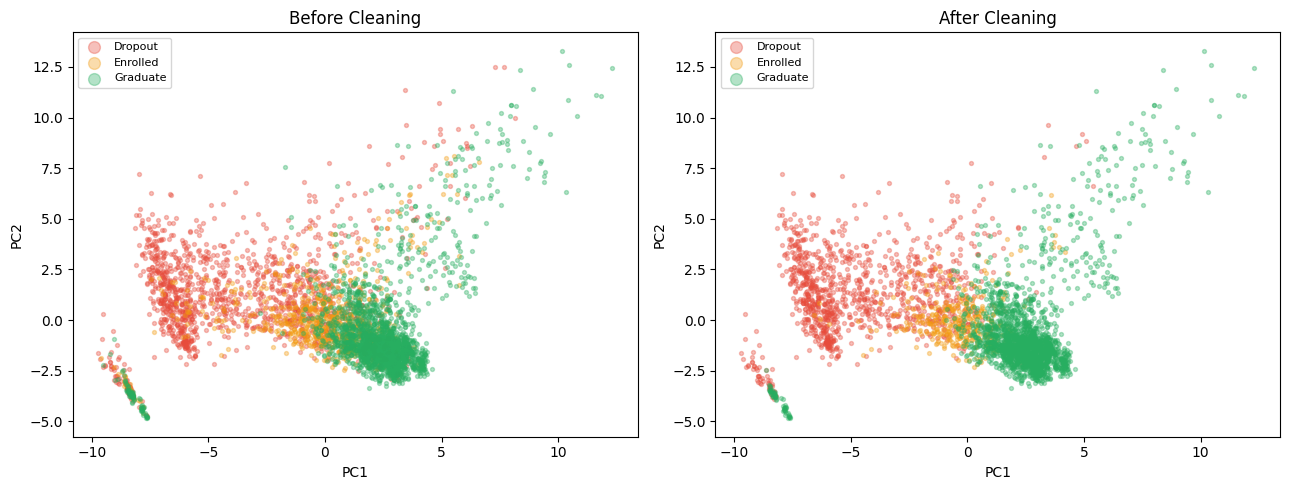

In [5]:
pca_vis   = PCA(n_components=2, random_state=42)
X_pca_all = pca_vis.fit_transform(X_sc_full)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {0: '#e74c3c', 1: '#f39c12', 2: '#27ae60'}
TARGET_NAMES = ['Dropout', 'Enrolled', 'Graduate']

for (title, mask) in [('Before Cleaning', np.ones(len(df), bool)), ('After Cleaning', clean_mask_full)]:
    ax = axes[0] if title == 'Before Cleaning' else axes[1]
    for cls in [0, 1, 2]:
        idx = np.where((y_full_arr == cls) & mask)[0]
        ax.scatter(X_pca_all[idx, 0], X_pca_all[idx, 1], c=colors[cls], label=TARGET_NAMES[cls], alpha=0.35, s=8)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig('../output/cleaning_full_pca.png', dpi=150, bbox_inches='tight')
plt.show()